In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
from scipy import stats
from statsmodels.stats.multitest import multipletests
from itertools import combinations

In [ ]:
df_anova = pd.read_csv(r"C:\Users\danil\Desktop\metrix\superset\ANOVA.csv")

Для начала посмотрим на наши данные визульно. Построим боксплот и распределения

In [4]:
df_anova = df_anova.sort_values('start_date')
control_dates = ['2025-11-06', '2025-11-13', '2025-11-20', '2025-11-27']

df_control = df_anova[df_anova['start_date'].isin(control_dates)].copy()
df_test = df_anova[df_anova['start_date'] == '2025-12-04'].copy()

print('Число пользователей в контрольной группе =', len(df_control))
print('Число пользователей в тествой группе =', len(df_test))

Число пользователей в контрольной группе = 2871
Число пользователей в тествой группе = 2238


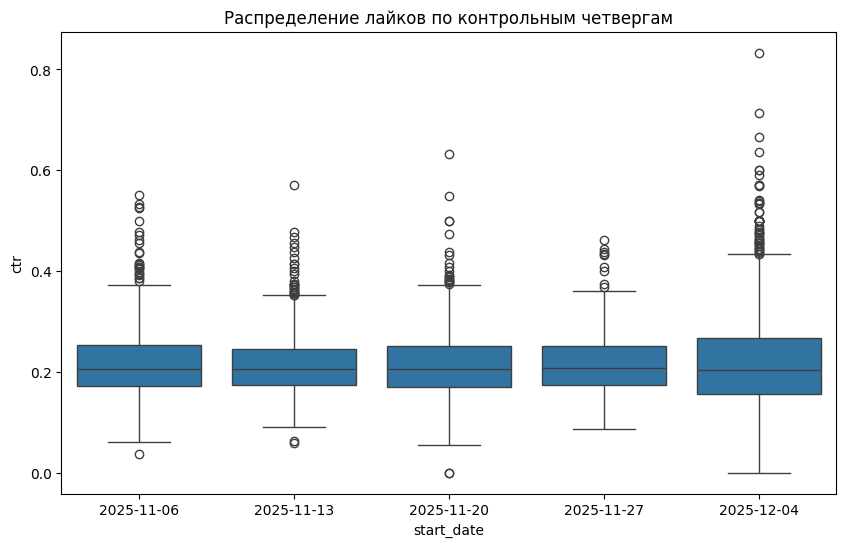

In [5]:
plt.figure(figsize=(10,6))
sns.boxplot(x='start_date', y='ctr', data=df_anova)
plt.title('Распределение лайков по контрольным четвергам')
plt.show()

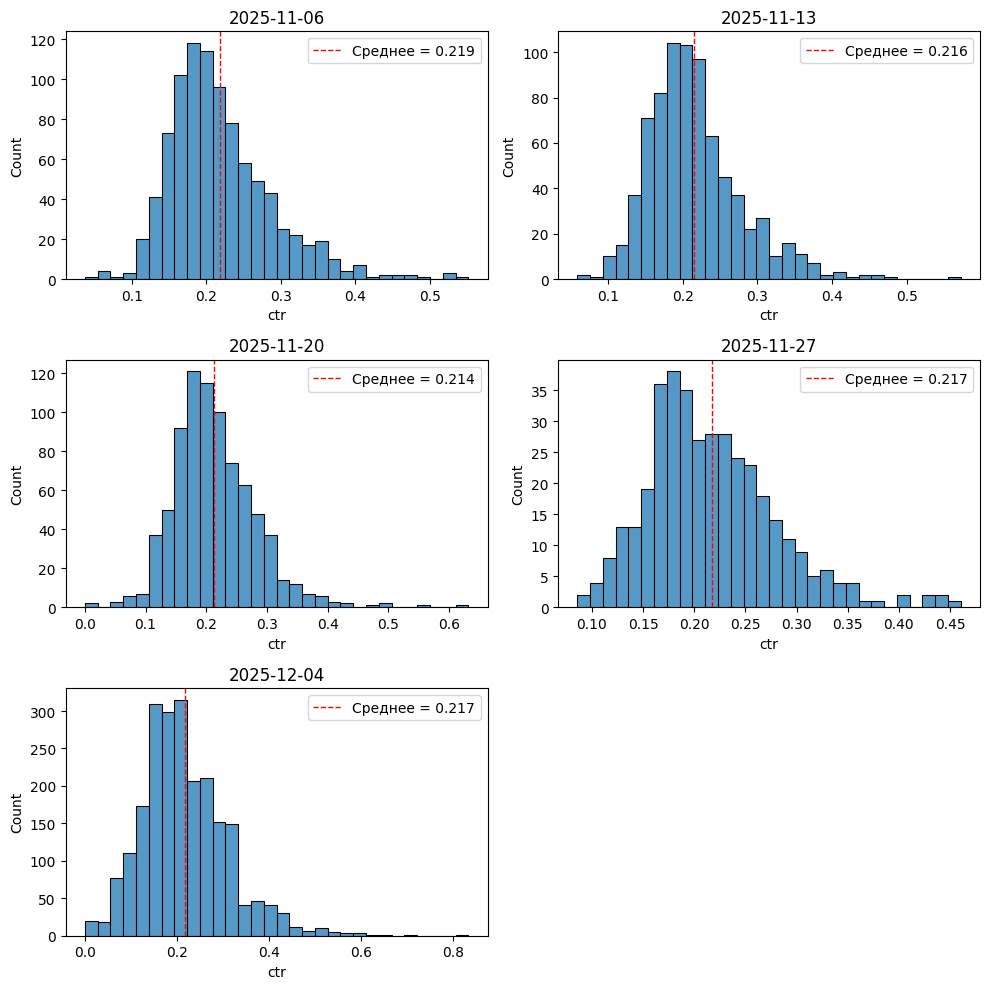

In [6]:
df_control_2025_11_06 = df_control.loc[df_control['start_date'] == '2025-11-06', ['likes', 'views', 'ctr', 'age']]
df_control_2025_11_13 = df_control.loc[df_control['start_date'] == '2025-11-13', ['likes', 'views', 'ctr', 'age']]
df_control_2025_11_20 = df_control.loc[df_control['start_date'] == '2025-11-20', ['likes', 'views', 'ctr', 'age']]
df_control_2025_11_27 = df_control.loc[df_control['start_date'] == '2025-11-27', ['likes', 'views', 'ctr', 'age']]

mean_06 = df_control_2025_11_06['ctr'].mean()
mean_13 = df_control_2025_11_13['ctr'].mean()
mean_20 = df_control_2025_11_20['ctr'].mean()
mean_27 = df_control_2025_11_27['ctr'].mean()
mean_test = df_test['ctr'].mean()

plt.figure(figsize= (10,10))

plt.subplot(3, 2, 1)
sns.histplot(df_control_2025_11_06['ctr'], bins=30)
plt.title("2025-11-06")
plt.axvline(mean_06, color='red', linestyle='--', linewidth=1, label=f'Среднее = {mean_06:.3f}')
plt.legend()

plt.subplot(3, 2, 2)
sns.histplot(df_control_2025_11_13['ctr'], bins=30)
plt.title("2025-11-13")
plt.axvline(mean_13, color='red', linestyle='--', linewidth=1, label=f'Среднее = {mean_13:.3f}')
plt.legend()

plt.subplot(3, 2, 3)
sns.histplot(df_control_2025_11_20['ctr'], bins=30)
plt.title("2025-11-20")
plt.axvline(mean_20, color='red', linestyle='--', linewidth=1, label=f'Среднее = {mean_20:.3f}')
plt.legend()

plt.subplot(3, 2, 4)
sns.histplot(df_control_2025_11_27['ctr'], bins=30)
plt.title("2025-11-27")
plt.axvline(mean_27, color='red', linestyle='--', linewidth=1, label=f'Среднее = {mean_27:.3f}')
plt.legend()

plt.subplot(3, 2, 5)
sns.histplot(df_test['ctr'], bins=30)
plt.title("2025-12-04")
plt.axvline(mean_test, color='red', linestyle='--', linewidth=1, label=f'Среднее = {mean_test:.3f}')
plt.legend()

plt.tight_layout()
plt.show()


### А/А тест для проверки ковариатов (пол, возраст, os)

Для начала попарно проверим возраст между днями с помощью теста Уэлча, применив поправку на множественную проверку гототез Холма. Видим, что ни одна из скорректированных p-value не опустилась ниже 0.05, то есть дни по возрасту однородны.

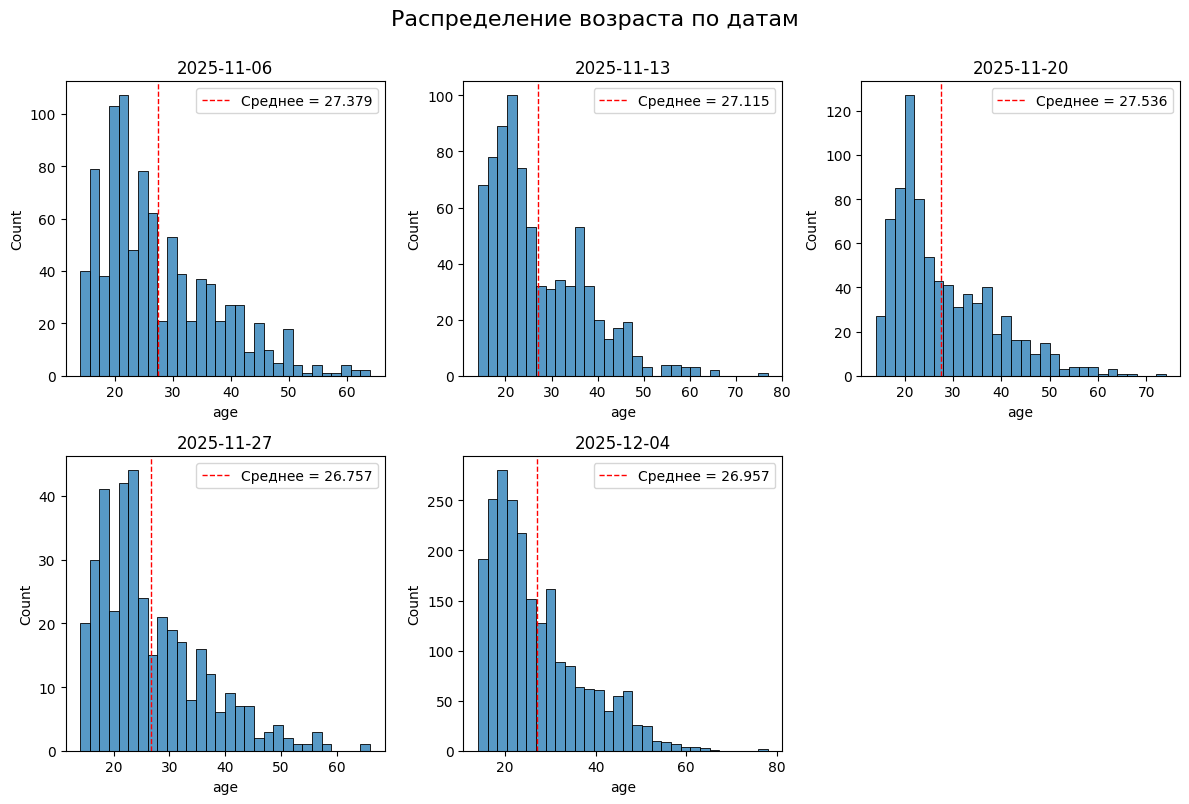

In [30]:
mean_06_age = df_control_2025_11_06['age'].mean()
mean_13_age = df_control_2025_11_13['age'].mean()
mean_20_age = df_control_2025_11_20['age'].mean()
mean_27_age = df_control_2025_11_27['age'].mean()
mean_test_age = df_test['age'].mean()


plt.figure(figsize= (12,8))
plt.suptitle('Распределение возраста по датам', fontsize=16, y=1)

plt.subplot(2, 3, 1)
sns.histplot(df_control_2025_11_06['age'], bins=30)
plt.title("2025-11-06")
plt.axvline(mean_06_age, color='red', linestyle='--', linewidth=1, label=f'Среднее = {mean_06_age:.3f}')
plt.legend()

plt.subplot(2, 3, 2)
sns.histplot(df_control_2025_11_13['age'], bins=30)
plt.title("2025-11-13")
plt.axvline(mean_13_age, color='red', linestyle='--', linewidth=1, label=f'Среднее = {mean_13_age:.3f}')
plt.legend()

plt.subplot(2, 3, 3)
sns.histplot(df_control_2025_11_20['age'], bins=30)
plt.title("2025-11-20")
plt.axvline(mean_20_age, color='red', linestyle='--', linewidth=1, label=f'Среднее = {mean_20_age:.3f}')
plt.legend()

plt.subplot(2, 3, 4)
sns.histplot(df_control_2025_11_27['age'], bins=30)
plt.title("2025-11-27")
plt.axvline(mean_27_age, color='red', linestyle='--', linewidth=1, label=f'Среднее = {mean_27_age:.3f}')
plt.legend()

plt.subplot(2, 3, 5)
sns.histplot(df_test['age'], bins=30)
plt.title("2025-12-04")
plt.axvline(mean_test_age, color='red', linestyle='--', linewidth=1, label=f'Среднее = {mean_test_age:.3f}')
plt.legend()

plt.tight_layout()
plt.show()

In [8]:
ctrl_days = {
    '2025-11-06': df_control_2025_11_06['age'],
    '2025-11-13': df_control_2025_11_13['age'],
    '2025-11-20': df_control_2025_11_20['age'],
    '2025-11-27': df_control_2025_11_27['age'],
    '2025-12-04': df_test['age']
}

results = []
for (day1, data1), (day2, data2) in combinations(ctrl_days.items(), 2):
    t_stat, p_val = stats.ttest_ind(data1, data2, equal_var=False)
    mean1 = data1.mean()
    mean2 = data2.mean()
    diff = mean1 - mean2
    results.append({
        'day1': day1,
        'day2': day2,
        'mean1': mean1,
        'mean2': mean2,
        'diff': diff,
        't_stat': t_stat,
        'p_value': p_val
    })

results_df = pd.DataFrame(results)


print("P-значения:")
print(results_df[['day1', 'day2', 'p_value']], '\n')


reject, p_corrected, _, _ = multipletests(results_df['p_value'], alpha=0.05, method='holm')

print(reject)

P-значения:
         day1        day2   p_value
0  2025-11-06  2025-11-13  0.588523
1  2025-11-06  2025-11-20  0.749148
2  2025-11-06  2025-11-27  0.288211
3  2025-11-06  2025-12-04  0.276716
4  2025-11-13  2025-11-20  0.416481
5  2025-11-13  2025-11-27  0.556567
6  2025-11-13  2025-12-04  0.708611
7  2025-11-20  2025-11-27  0.202276
8  2025-11-20  2025-12-04  0.172954
9  2025-11-27  2025-12-04  0.706955 

[False False False False False False False False False False]


Проверим, есть ли разница между соотношениями полов и os по дате или нет с помошью хи^2 и таблицы сопряженности

In [9]:
contingency_sex = pd.crosstab(df_anova['start_date'], df_anova['gender']) # создаем частотную таблицу
chi2, p_global_sex, dof, expected = stats.chi2_contingency(contingency_sex)
print(f"Глобальный тест для пола: p = {p_global_sex:.4f}")

Глобальный тест для пола: p = 0.3578


In [10]:
contingency_sex = pd.crosstab(df_anova['start_date'], df_anova['os'])
chi2, p_global_sex, dof, expected = stats.chi2_contingency(contingency_sex)
print(f"Глобальный тест для os: p = {p_global_sex:.4f}")

Глобальный тест для os: p = 0.2214


Для обоих случаев p-value > 0.05. Таким образом из проверки по ковариатам можно сделать вывод, что тестовая и контрольные группы однородны и их можно брать для дальнейшего А/Б

### A/A Тест для проверки репрезентативности по метрикам likes, views, CTR

Проведем попарные тесты для того, чтобы выяснить, есть ли различия в средних в наших днях и можно ли их объединить в одну контрольную группу. Для начала сделаем это с CTR.

Однако в данном случае к поюзерному CTR нужен особый подход, так как это retio-метрика. Проблема в том, что если просто усреднить персональные CTR по пользователям, то пользователи с малым числом просмотров получат такой же вес, как и пользователи с большим числом просмотров, хотя их вклад в общий CTR (сумма лайков / сумма просмотров) несопоставим.
Чтобы корректно сравнить CTR между днями, используют общегрупповой CTR (сумма лайков в выборке / сумма просмотров в выборке).

In [11]:
def bootstrap_group_ctr(df, n_bootstrap=2000):
   
    n_users = len(df)
    boot_ctrs = np.empty(n_bootstrap)
    
    for i in range(n_bootstrap):
        
        sample = df.sample(n=n_users, replace=True)
        total_likes = sample['likes'].sum()
        total_views = sample['views'].sum()
        boot_ctrs[i] = total_likes / total_views
    
    return boot_ctrs


control_dfs = {
    '2025-11-06': df_control_2025_11_06,
    '2025-11-13': df_control_2025_11_13,
    '2025-11-20': df_control_2025_11_20,
    '2025-11-27': df_control_2025_11_27
}


results = []

for day1, day2 in combinations(control_dfs.keys(), 2):
    
    boot1 = bootstrap_group_ctr(control_dfs[day1])
    boot2 = bootstrap_group_ctr(control_dfs[day2])
    
    diff = boot1 - boot2  # разность бутстрап-значений
    
    # Двустороннее p-value
    p_value = 2 * min(np.mean(diff > 0), np.mean(diff < 0))
    
    # Можно также сохранить доверительный интервал разности
    ci_low = np.percentile(diff, 2.5)
    ci_high = np.percentile(diff, 97.5)
    
    results.append({
        'day1': day1,
        'day2': day2,
        'p_value': p_value,
        'ci_low': ci_low,
        'ci_high': ci_high,
        'diff_mean': np.mean(diff),
        'diff': diff 
    })

# Преобразуем в DataFrame для удобства
results_df = pd.DataFrame(results)
print(results_df)

         day1        day2  p_value    ci_low   ci_high  diff_mean  \
0  2025-11-06  2025-11-13    0.425 -0.003265  0.007916   0.002316   
1  2025-11-06  2025-11-20    0.299 -0.002915  0.008862   0.003047   
2  2025-11-06  2025-11-27    0.695 -0.009844  0.006300  -0.001669   
3  2025-11-13  2025-11-20    0.785 -0.004772  0.006396   0.000756   
4  2025-11-13  2025-11-27    0.355 -0.011988  0.003920  -0.003818   
5  2025-11-20  2025-11-27    0.248 -0.012256  0.003295  -0.004631   

                                                diff  
0  [0.006520335794605897, -0.002595948493490763, ...  
1  [0.0030850872992699008, 0.005691053389711348, ...  
2  [0.00013325465022689942, -0.003740194245723444...  
3  [-0.0021220158591276073, 0.0017834829972417088...  
4  [0.0020875361510288015, -0.004369841353887821,...  
5  [-0.009533093819696387, -0.011188921655903905,...  


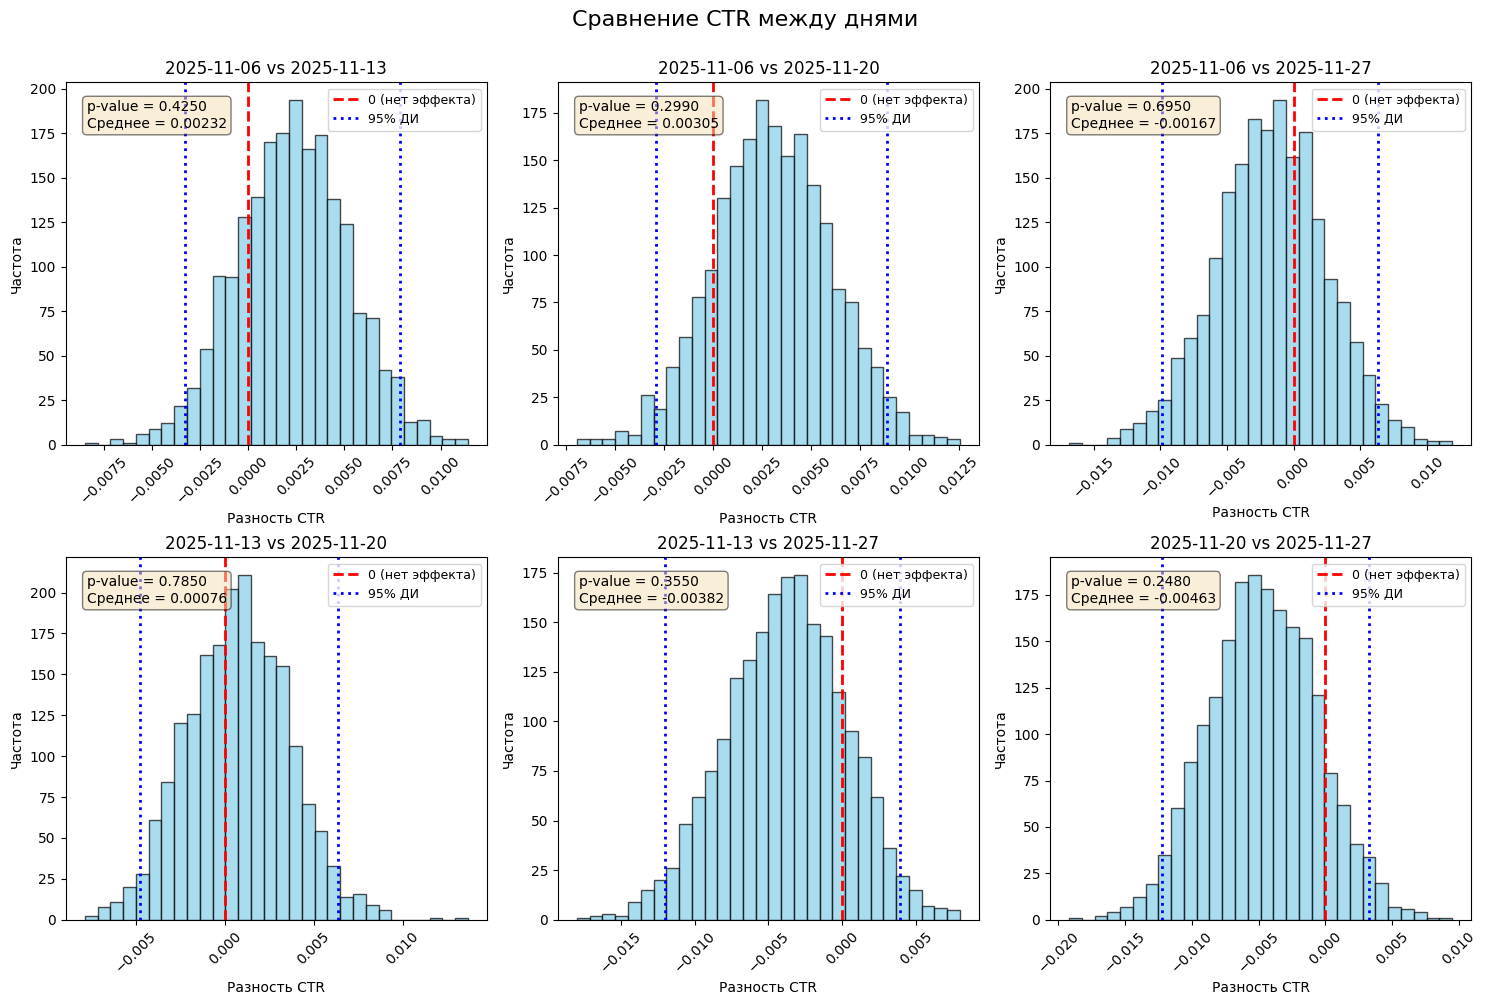

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, res in enumerate(results):
    ax = axes[idx]
    diff = res['diff']
    
    # Гистограмма распределения разности
    ax.hist(diff, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    ax.axvline(0, color='red', linestyle='--', linewidth=2)
    ax.axvline(res['ci_low'], color='blue', linestyle=':', linewidth=2)
    ax.axvline(res['ci_high'], color='blue', linestyle=':', linewidth=2)
    
    # Заголовок и подписи осей
    ax.set_title(f"{res['day1']} vs {res['day2']}")
    ax.set_xlabel('Разность CTR')
    ax.set_ylabel('Частота')
    
    # Текстовая информация (p-value и среднее) в левом верхнем углу
    textstr = f"p-value = {res['p_value']:.4f}\nСреднее = {res['diff_mean']:.5f}"
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Кастомная легенда для линий в правом верхнем углу
    legend_elements = [
        Line2D([0], [0], color='red', linestyle='--', linewidth=2, label='0 (нет эффекта)'),
        Line2D([0], [0], color='blue', linestyle=':', linewidth=2, label='95% ДИ')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=9)
    
    # Поворот подписей оси x для читаемости
    ax.tick_params(axis='x', rotation=45)
    
fig.suptitle('Сравнение CTR между днями', fontsize=16, y=1)  # y регулирует отступ сверху

# Скрываем лишние подграфики (если их меньше 6)
for j in range(len(results), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Сделаем коррекцию на множественные сравнения Холма. Т.к у нас везде False, то можно сделать вывод что, уже с поправкой, дни значимо не различаются между собой.

In [13]:
reject, p_corrected, _, _ = multipletests(results_df['p_value'], alpha=0.05, method='holm')

print(reject)

[False False False False False False]


### Теперь проведем А/Б тест и узнаем, статистически ли значимо различаются метрики по CTR у наших групп.

Сделаем это также с помощью бутстрапа

0.175


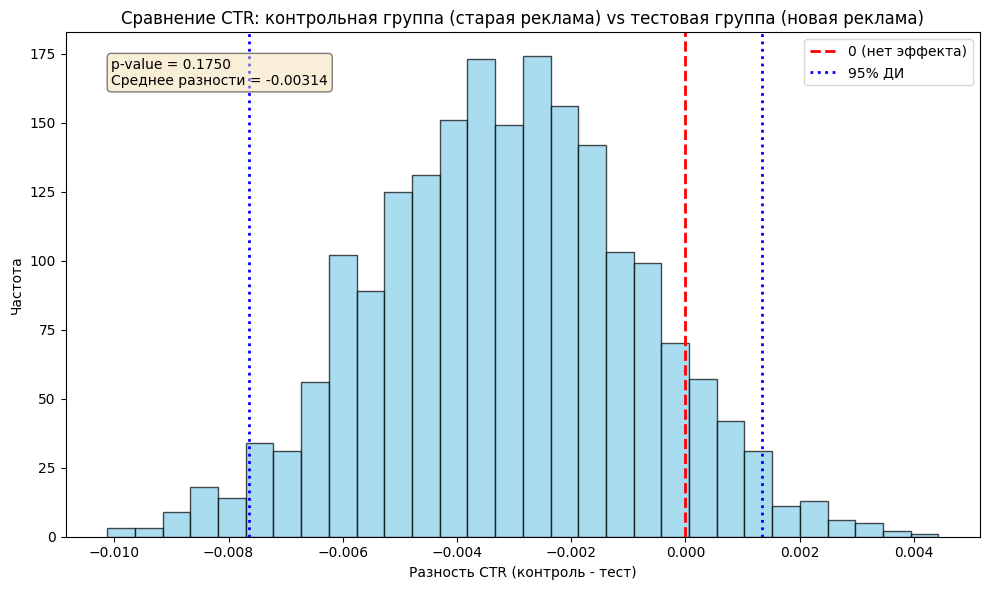

In [14]:
boot_ctr_day1 = bootstrap_group_ctr(df_control)
boot_ctr_day2 = bootstrap_group_ctr(df_test)

diff = boot_ctr_day1 - boot_ctr_day2
p_value = 2 * min(np.mean(diff>0), np.mean(diff<0))

print(p_value)

fig, ax = plt.subplots(figsize=(10, 6))

# Гистограмма распределения разности
ax.hist(diff, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
ax.axvline(0, color='red', linestyle='--', linewidth=2, label='0 (нет эффекта)')

# Доверительный интервал разности (2.5% и 97.5% процентили)
ci_low = np.percentile(diff, 2.5)
ci_high = np.percentile(diff, 97.5)
ax.axvline(ci_low, color='blue', linestyle=':', linewidth=2, label='95% ДИ')
ax.axvline(ci_high, color='blue', linestyle=':', linewidth=2)

# Подписи осей и заголовок
ax.set_title('Сравнение CTR: контрольная группа (старая реклама) vs тестовая группа (новая реклама)')
ax.set_xlabel('Разность CTR (контроль - тест)')
ax.set_ylabel('Частота')

# Текстовая информация на графике (p-value и средняя разность)
textstr = f"p-value = {p_value:.4f}\nСреднее разности = {np.mean(diff):.5f}"
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.legend()
plt.tight_layout()
plt.show()

**Предварительный вывод**

Мы не получили статистически значимого результата, который позволил бы нам отклонить нулевую гипотезу о равенстве средних, поэтому будем считать, что разницы по метрике CTR обнаружено не было. Однако то, что статистический тест по метрике CTR тестовой группы значимо не отличился от контрольной не делает группы равноценными по "качеству" пользователей. Вполне можно представить, что в группы значимо отличаются друг от друга по количеству лайков или просмотров, однако соотношение likes/views у них примерно одинаково и не дает статистически значимый результат. Поэтому теперь надо сравнить количество лайков и просмотров между группами.

Теперь попарно сравним все дни между собой по количеству лайков и просмотров на пользователя. Но для начала посмотрим, можно ли наши 4 дня из контрольной группы объединить уже на основе метрик likes и views.

Для начала попарно сравним лайки

In [32]:
def pair_compare(data, metric):

    thursdays = data['start_date'].unique()
    
    means_dict = {}
    p_values = []
    compares = ''
    
    for day in thursdays:
        means_dict[day] = round(np.mean(data.loc[data['start_date'] == day, metric]), 4)

    for day1, day2 in combinations(thursdays, 2):
        data1 = data[data['start_date'] == day1][metric]
        data2 = data[data['start_date'] == day2][metric]
        p = stats.ttest_ind(data1, data2, equal_var=False).pvalue
        p_values.append(p)
        compares += f"{day1} vs {day2}: p={p:.4f}\n"
    
    sorted_means = dict(sorted(means_dict.items(), key=lambda item: item[1]))
    
    return compares, sorted_means, p_values

compares, sorted_means, p_values = pair_compare(df_control, 'likes')

print('Попарное сравнение дней по количеству лайков на пользователя')
print(compares, '\n', 'Средние для каждого дня по возрастанию:\n', sorted_means, '\n\n')

Попарное сравнение дней по количеству лайков на пользователя
2025-11-06 vs 2025-11-13: p=0.0187
2025-11-06 vs 2025-11-20: p=0.0000
2025-11-06 vs 2025-11-27: p=0.0000
2025-11-13 vs 2025-11-20: p=0.0069
2025-11-13 vs 2025-11-27: p=0.0000
2025-11-20 vs 2025-11-27: p=0.0011
 
 Средние для каждого дня по возрастанию:
 {'2025-11-06': np.float64(24.5289), '2025-11-13': np.float64(26.1788), '2025-11-20': np.float64(28.24), '2025-11-27': np.float64(32.2354)} 




Видим, что все контрольные дни значимо отличаются друг от друга, значит объединять их нельзя. А что насчет просмотров?

In [16]:
compares, sorted_means, p_values = pair_compare(df_control, 'views')

print('Попарное сравнение дней по количеству просмотров на пользователя')
print(compares, '\n', 'Средние для каждого дня по возрастанию:\n', sorted_means, '\n\n')

Попарное сравнение дней по количеству просмотров на пользователя
2025-11-06 vs 2025-11-13: p=0.0040
2025-11-06 vs 2025-11-20: p=0.0000
2025-11-06 vs 2025-11-27: p=0.0000
2025-11-13 vs 2025-11-20: p=0.0026
2025-11-13 vs 2025-11-27: p=0.0000
2025-11-20 vs 2025-11-27: p=0.0023
 
 Средние для каждого дня по возрастанию:
 {'2025-11-06': np.float64(115.5812), '2025-11-13': np.float64(124.7383), '2025-11-20': np.float64(134.9826), '2025-11-27': np.float64(150.7619)} 




Просмотры также значимо отличаются друг от друга. В таком случае, если дни нельзя объединить ни по просмотрам, ни по лайкам, можно попарно сравнить эти дни с тестовой группой и если вдруг окажется, что она по результатам среднего будет значимо хуже всех, то можно будет сказать, что по показателям абсолютных значений лайков и просмотров пользователи из тестовой группы имеют меньшую активность в лайках и просмотрах чем пользователи из контрольной

In [17]:
def pair_compare_test_control(test_date, test_data, metric, data_dict):
    
    means_dict = {test_date: test_data[metric].mean()}
    p_values = []
    compares = ''

    for day, df_control in data_dict.items():
        data1 = test_data[metric]
        data2 = df_control[metric]

        means_dict[day] = np.mean(data2)
        
        p = stats.ttest_ind(data1, data2, equal_var=False).pvalue
        p_values.append(p)
        compares += f"{test_date} vs {day}: p={p:.4f}\n"

    sorted_means = dict(sorted(means_dict.items(), key=lambda item: item[1]))
    
    return compares, sorted_means, p_values
    
    
compares, sorted_means, p_values = pair_compare_test_control('2025-12-04', df_test, 'likes', control_dfs)

print('Попарное сравнение дней по количеству лайков на пользователя')
print(compares, '\n', 'Средние для каждого дня по возрастанию:\n', sorted_means, '\n\n')

reject, p_corrected, _, _ = multipletests(p_values, alpha=0.05, method='holm')

print(reject)

Попарное сравнение дней по количеству лайков на пользователя
2025-12-04 vs 2025-11-06: p=0.0000
2025-12-04 vs 2025-11-13: p=0.0000
2025-12-04 vs 2025-11-20: p=0.0000
2025-12-04 vs 2025-11-27: p=0.0000
 
 Средние для каждого дня по возрастанию:
 {'2025-12-04': np.float64(13.078194816800714), '2025-11-06': np.float64(24.528898582333696), '2025-11-13': np.float64(26.178756476683937), '2025-11-20': np.float64(28.24004975124378), '2025-11-27': np.float64(32.235449735449734)} 


[ True  True  True  True]


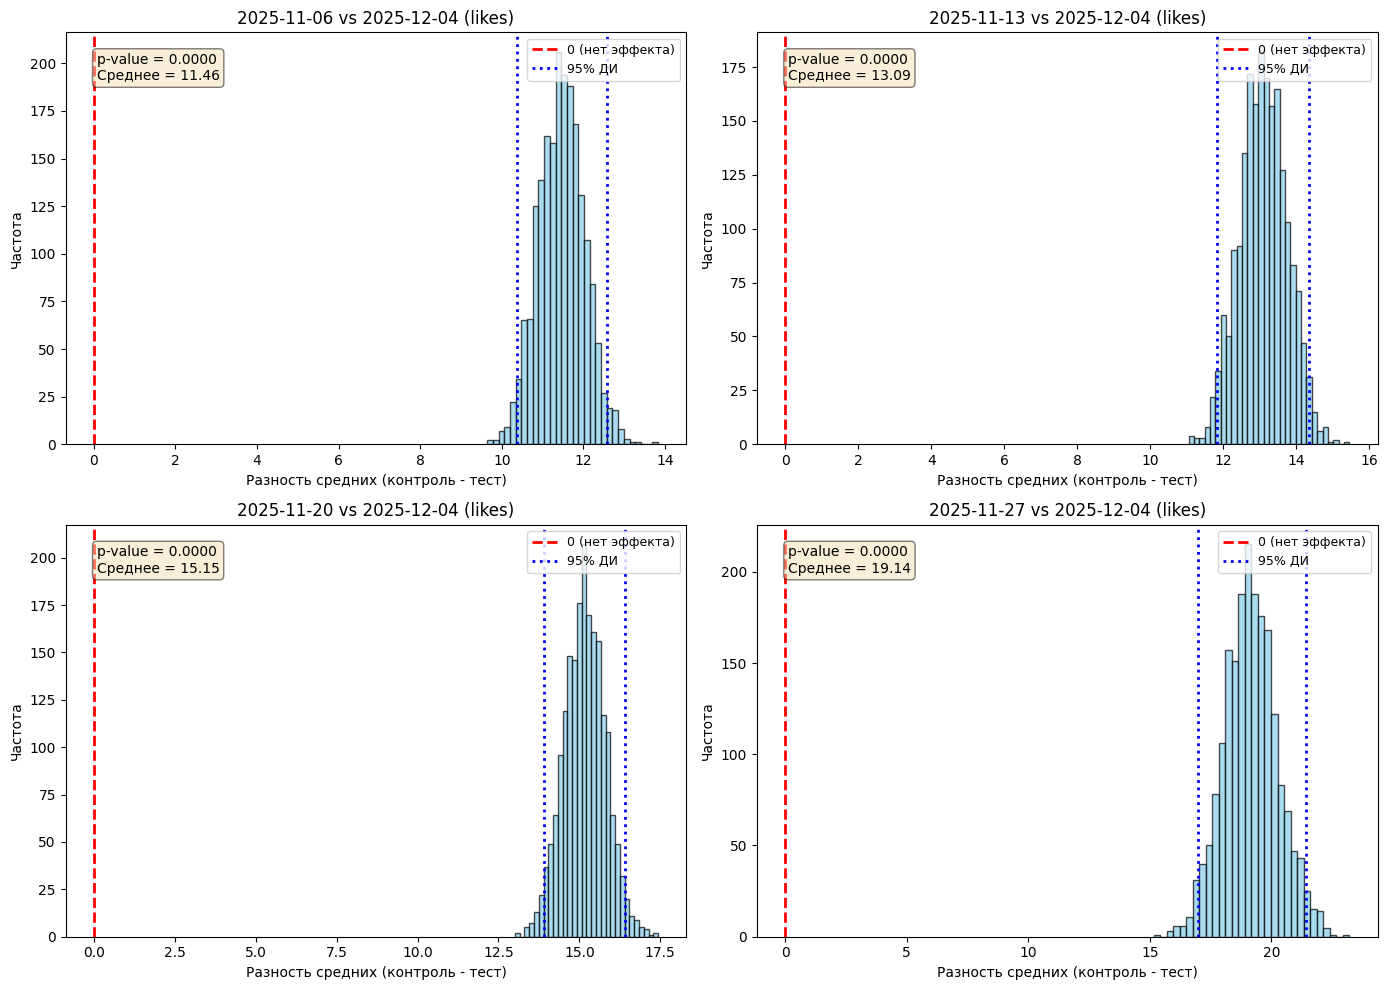

In [18]:
# Функция бутстрепа разности средних
def bootstrap_mean_diff(data1, data2, n_bootstrap=2000):
    n1, n2 = len(data1), len(data2)
    diff = np.empty(n_bootstrap)
    for i in range(n_bootstrap):
        sample1 = np.random.choice(data1, size=n1, replace=True)
        sample2 = np.random.choice(data2, size=n2, replace=True)
        diff[i] = np.mean(sample1) - np.mean(sample2)
    return diff

# Данные тестового дня (лайки)
test_date = '2025-12-04'
test_likes = df_test['likes'].values

# Контрольные четверги
control_dates = ['2025-11-06', '2025-11-13', '2025-11-20', '2025-11-27']
results_likes = []

for day in control_dates:
    control_likes = control_dfs[day]['likes'].values
    diff = bootstrap_mean_diff(control_likes, test_likes)
    p_value = 2 * min(np.mean(diff > 0), np.mean(diff < 0))
    ci_low = np.percentile(diff, 2.5)
    ci_high = np.percentile(diff, 97.5)
    diff_mean = np.mean(diff)
    results_likes.append({
        'day1': day,
        'day2': test_date,
        'diff': diff,
        'p_value': p_value,
        'ci_low': ci_low,
        'ci_high': ci_high,
        'diff_mean': diff_mean
    })

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, res in enumerate(results_likes):
    ax = axes[idx]
    diff = res['diff']
    
    # Гистограмма
    ax.hist(diff, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    
    # Линии
    ax.axvline(0, color='red', linestyle='--', linewidth=2)
    ax.axvline(res['ci_low'], color='blue', linestyle=':', linewidth=2)
    ax.axvline(res['ci_high'], color='blue', linestyle=':', linewidth=2)
    
    # Кастомная легенда (в правом верхнем углу)
    legend_elements = [
        Line2D([0], [0], color='red', linestyle='--', linewidth=2, label='0 (нет эффекта)'),
        Line2D([0], [0], color='blue', linestyle=':', linewidth=2, label='95% ДИ')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=9)
    
    # Текстовая метка с p-value и средним (левый верхний угол)
    textstr = f"p-value = {res['p_value']:.4f}\nСреднее = {res['diff_mean']:.2f}"
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Заголовок и подписи осей
    ax.set_title(f"{res['day1']} vs {res['day2']} (likes)")
    ax.set_xlabel('Разность средних (контроль - тест)')
    ax.set_ylabel('Частота')

plt.tight_layout()
plt.show()

Все нулевые гипотезы были отвергнуты и среднее тестового дня имеет наименьшее значение. А что с просмотрами?

In [19]:
compares, sorted_means, p_values = pair_compare_test_control('2025-12-04', df_test, 'views', control_dfs)

print('Попарное сравнение дней по количеству лайков на пользователя')
print(compares, '\n', 'Средние для каждого дня по возрастанию:\n', sorted_means, '\n\n')

reject, p_corrected, _, _ = multipletests(p_values, alpha=0.05, method='holm')

print(reject)

Попарное сравнение дней по количеству лайков на пользователя
2025-12-04 vs 2025-11-06: p=0.0000
2025-12-04 vs 2025-11-13: p=0.0000
2025-12-04 vs 2025-11-20: p=0.0000
2025-12-04 vs 2025-11-27: p=0.0000
 
 Средние для каждого дня по возрастанию:
 {'2025-12-04': np.float64(61.09651474530831), '2025-11-06': np.float64(115.58124318429662), '2025-11-13': np.float64(124.73834196891191), '2025-11-20': np.float64(134.9825870646766), '2025-11-27': np.float64(150.76190476190476)} 


[ True  True  True  True]


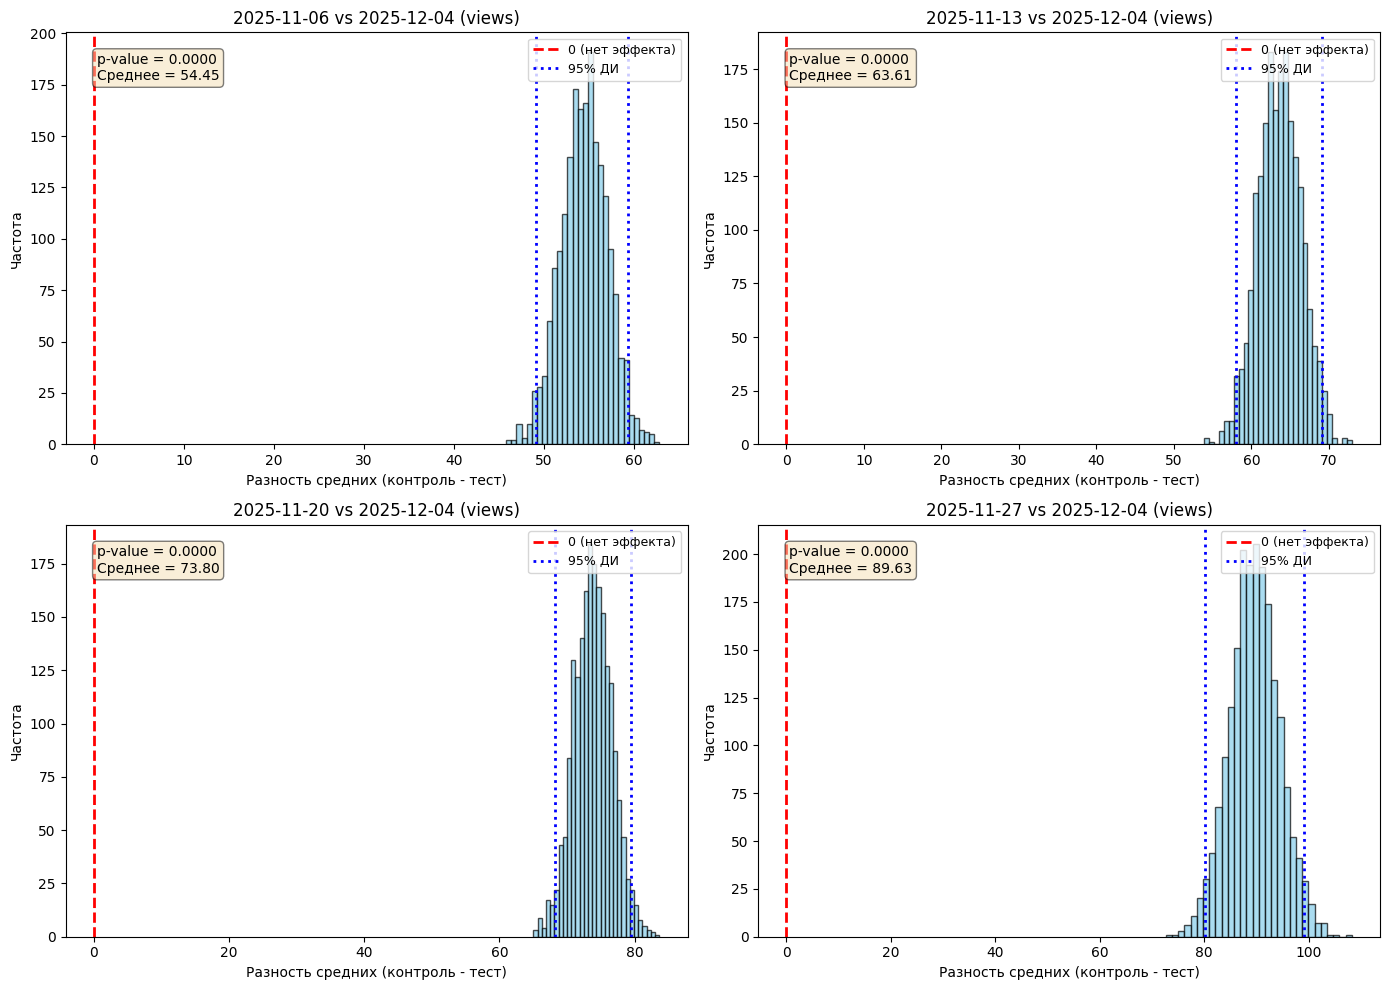

In [20]:
# Функция бутстрепа разности средних
def bootstrap_mean_diff(data1, data2, n_bootstrap=2000):
    n1, n2 = len(data1), len(data2)
    diff = np.empty(n_bootstrap)
    for i in range(n_bootstrap):
        sample1 = np.random.choice(data1, size=n1, replace=True)
        sample2 = np.random.choice(data2, size=n2, replace=True)
        diff[i] = np.mean(sample1) - np.mean(sample2)
    return diff

# Данные тестового дня (лайки)
test_date = '2025-12-04'
test_likes = df_test['views'].values

# Контрольные четверги
control_dates = ['2025-11-06', '2025-11-13', '2025-11-20', '2025-11-27']
results_likes = []

for day in control_dates:
    control_likes = control_dfs[day]['views'].values
    diff = bootstrap_mean_diff(control_likes, test_likes)
    p_value = 2 * min(np.mean(diff > 0), np.mean(diff < 0))
    ci_low = np.percentile(diff, 2.5)
    ci_high = np.percentile(diff, 97.5)
    diff_mean = np.mean(diff)
    results_likes.append({
        'day1': day,
        'day2': test_date,
        'diff': diff,
        'p_value': p_value,
        'ci_low': ci_low,
        'ci_high': ci_high,
        'diff_mean': diff_mean
    })

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, res in enumerate(results_likes):
    ax = axes[idx]
    diff = res['diff']
    
    # Гистограмма
    ax.hist(diff, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    
    # Линии
    ax.axvline(0, color='red', linestyle='--', linewidth=2)
    ax.axvline(res['ci_low'], color='blue', linestyle=':', linewidth=2)
    ax.axvline(res['ci_high'], color='blue', linestyle=':', linewidth=2)
    
    # Кастомная легенда (в правом верхнем углу)
    legend_elements = [
        Line2D([0], [0], color='red', linestyle='--', linewidth=2, label='0 (нет эффекта)'),
        Line2D([0], [0], color='blue', linestyle=':', linewidth=2, label='95% ДИ')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=9)
    
    # Текстовая метка с p-value и средним (левый верхний угол)
    textstr = f"p-value = {res['p_value']:.4f}\nСреднее = {res['diff_mean']:.2f}"
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Заголовок и подписи осей
    ax.set_title(f"{res['day1']} vs {res['day2']} (views)")
    ax.set_xlabel('Разность средних (контроль - тест)')
    ax.set_ylabel('Частота')

plt.tight_layout()
plt.show()

Мы видим следующее:

Что по лайкам, что по просмотрам, от четверга к четвергу при старой рекламе у нас количество просмотров и лайков значимо увеличивалось каждую неделю. При этом пользователи, привлеченные с помощью новой рекламы, имели значимо меньшую метрику и в том и другом. Из этого можно сделать вывод, что тестовый день (новая реклама) значимо отличается от каждого из контрольных четвергов по лайкам и просмотрам (p-значения практически нулевые), это свидетельствует о том, что пользователи, привлечённые новой рекламой, имеют более низкую абсолютную активность.  Отсутствие различий в CTR при этом показывает, что относительная вовлечённость (лайки на просмотр) у них такая же, как у старых пользователей, но они просто меньше потребляют контент. 

То есть можно сделать следующий вывод:

1. По лайкам и просмотрам новая реклама привлекла статистически значимо менее активных пользователей
2. По CTR различий нет, значит, их «качество» как отношение лайков к просмотрам не хуже, но абсолютная вовлечённость ниже.